In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.thorlabs import ThorCam

from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography import toolbox
from slmsuite.holography.algorithms import SpotHologram


c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


In [2]:
cam = ThorCam()

TLCameraSDK initializing... success
Looking for cameras... success
ThorCam sn '38459' initializing... success


In [3]:
lut_path = "interpolated_voltage.lut"

slm = Meadowlark(lut_path=lut_path, wav_um=.688, settle_time_s=.3)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...

In [4]:
fs = FourierSLM(cam, slm)

In [5]:
cam.set_exposure(0.1)

0.100008

In [6]:
"""
fs.fourier_calibrate(
    array_center=(475,0),
    array_shape=10,                 # Size of the calibration grid (Nx, Ny) [#]
    array_pitch=40,                 # Pitch of the calibration grid (x, y) [knm]
    plot=2
);
"""

#fs.save_calibration("fourier")

fs.load_calibration("fourier")

'c:\\Users\\Xander\\Documents\\Code\\slm\\38459-Meadowlark HDMI-fourier-calibration_00002.h5'

In [7]:
def spot_array_points(n, center, span):
    """
    Generate an NxN array of spots using blazed gratings.

    center: (kx, ky) center of the array
    span:   +/- range around center in (kx, ky)
    """

    x0, y0 = center
    dx, dy = span

    xs = np.linspace(x0 - dx, x0 + dx, n)
    ys = np.linspace(y0 - dy, y0 + dy, n)

    # generate an array of points

    # use np.vstack to create a 2D array of points

    xgrid, ygrid = np.meshgrid(xs, ys)
    points = np.vstack((xgrid.ravel(), ygrid.ravel()))

    return points


# Example
n = 4
points_kxy = spot_array_points(
    n=n,
    center=(0.02, 0.00),
    #center=(0.00, 0.00),
    span=(0.0013, 0.0013)
    #span=(0.03, 0.03),
)

print(points_kxy)

[[ 0.0187      0.01956667  0.02043333  0.0213      0.0187      0.01956667
   0.02043333  0.0213      0.0187      0.01956667  0.02043333  0.0213
   0.0187      0.01956667  0.02043333  0.0213    ]
 [-0.0013     -0.0013     -0.0013     -0.0013     -0.00043333 -0.00043333
  -0.00043333 -0.00043333  0.00043333  0.00043333  0.00043333  0.00043333
   0.0013      0.0013      0.0013      0.0013    ]]


In [8]:
points_ij = toolbox.convert_vector(
    points_kxy,
    from_units="kxy",
    to_units="ij",
    hardware=fs,
)

print(points_ij)

[[794.38211608 794.48586881 794.58962154 794.69337427 802.37005205
  802.47380478 802.57755751 802.68131023 810.35798801 810.46174074
  810.56549347 810.6692462  818.34592398 818.44967671 818.55342944
  818.65718217]
 [572.05083532 564.02630058 556.00176583 547.97723108 572.14684812
  564.12231338 556.09777863 548.07324389 572.24286093 564.21832618
  556.19379144 548.16925669 572.33887373 564.31433899 556.28980424
  548.26526949]]


In [9]:
points_knm = toolbox.convert_vector(
    points_kxy,
    from_units="kxy",
    to_units="knm",
    hardware=fs,
)

print(points_knm)

[[1377.48837209 1396.8372093  1416.18604651 1435.53488372 1377.48837209
  1396.8372093  1416.18604651 1435.53488372 1377.48837209 1396.8372093
  1416.18604651 1435.53488372 1377.48837209 1396.8372093  1416.18604651
  1435.53488372]
 [ 581.86046512  581.86046512  581.86046512  581.86046512  593.95348837
   593.95348837  593.95348837  593.95348837  606.04651163  606.04651163
   606.04651163  606.04651163  618.13953488  618.13953488  618.13953488
   618.13953488]]


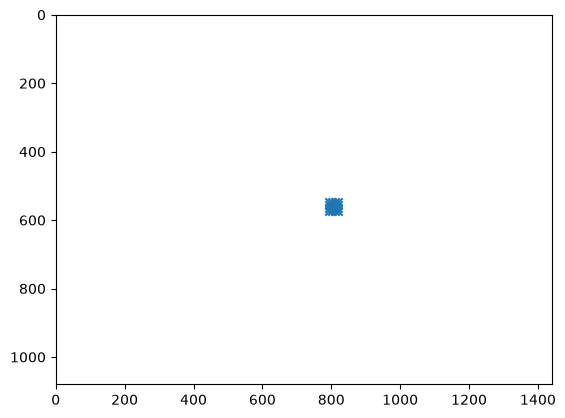

In [10]:
plt.scatter(points_ij[0,:], points_ij[1,:], marker='x')                               # Plot the points
plt.xlim([0, fs.cam.shape[1]]); plt.ylim([fs.cam.shape[0], 0])
#plt.xlim([800, 1200]); plt.ylim([400, 600])
plt.show()

In [11]:
hologram = SpotHologram(shape=(2048, 2048), spot_vectors=points_kxy, basis='kxy', cameraslm=fs)

(<Axes: xlabel='SLM $n$ [pix]', ylabel='SLM $m$ [pix]'>,
 <Axes: xlabel='Camera $i$ [pix]', ylabel='Camera $j$ [pix]'>)

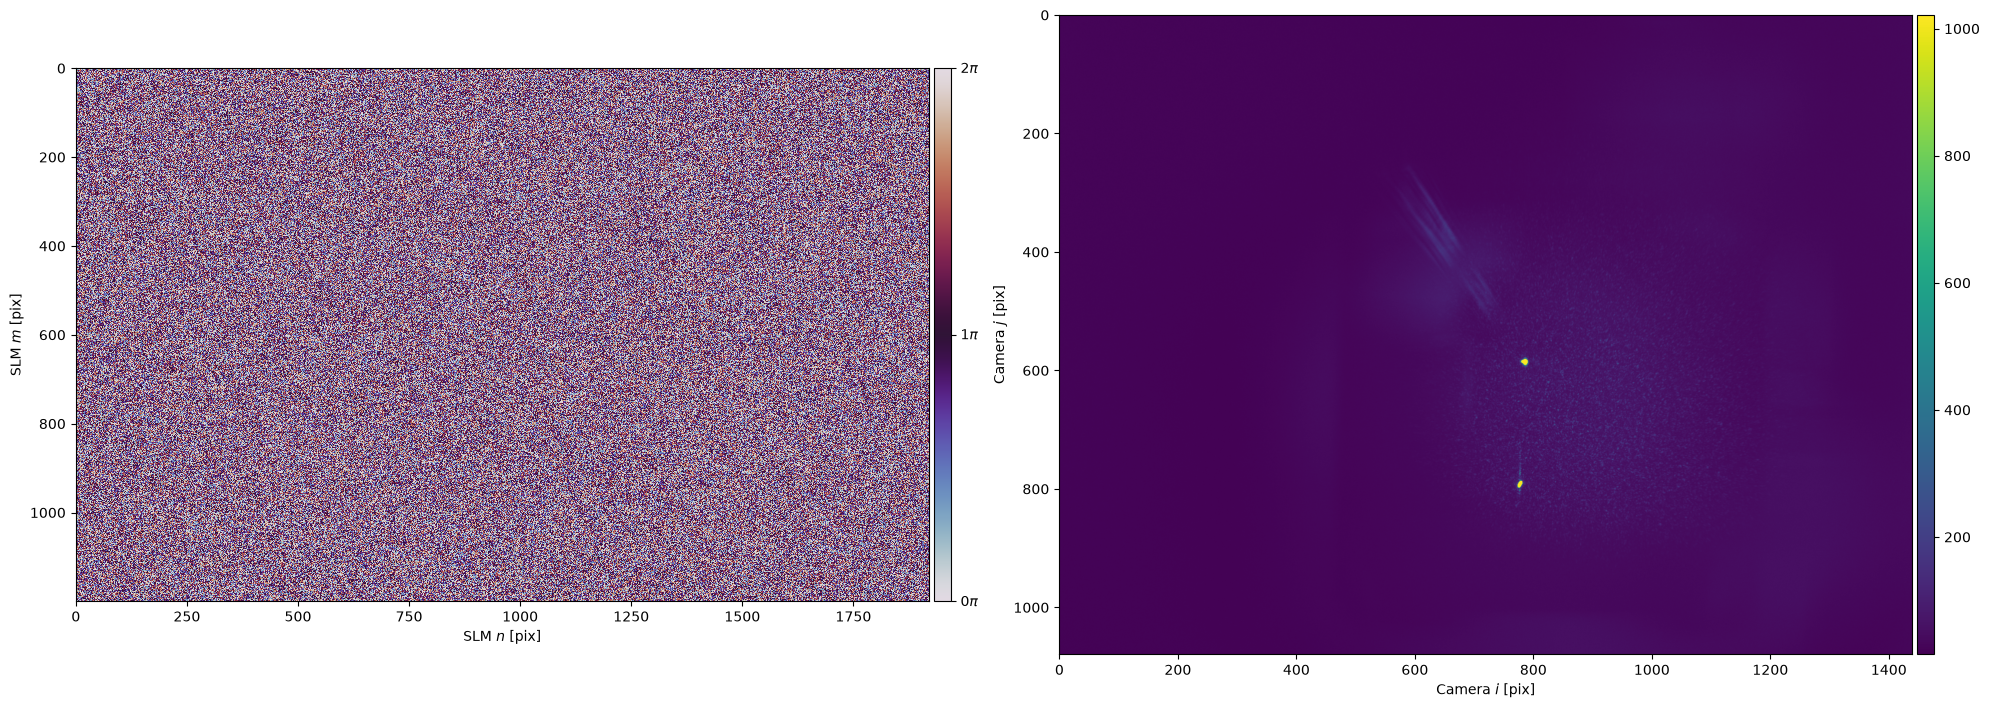

In [12]:
fs.plot(hologram.get_phase())

In [13]:
hologram.optimize('WGS-Kim', feedback='computational_spot', stat_groups=['computational_spot'], maxiter=20)

  0%|          | 0/20 [00:00<?, ?it/s]

In [14]:
cam.set_exposure(1.0)

1.000001

(<Axes: xlabel='SLM $n$ [pix]', ylabel='SLM $m$ [pix]'>,
 <Axes: xlabel='Camera $i$ [pix]', ylabel='Camera $j$ [pix]'>)

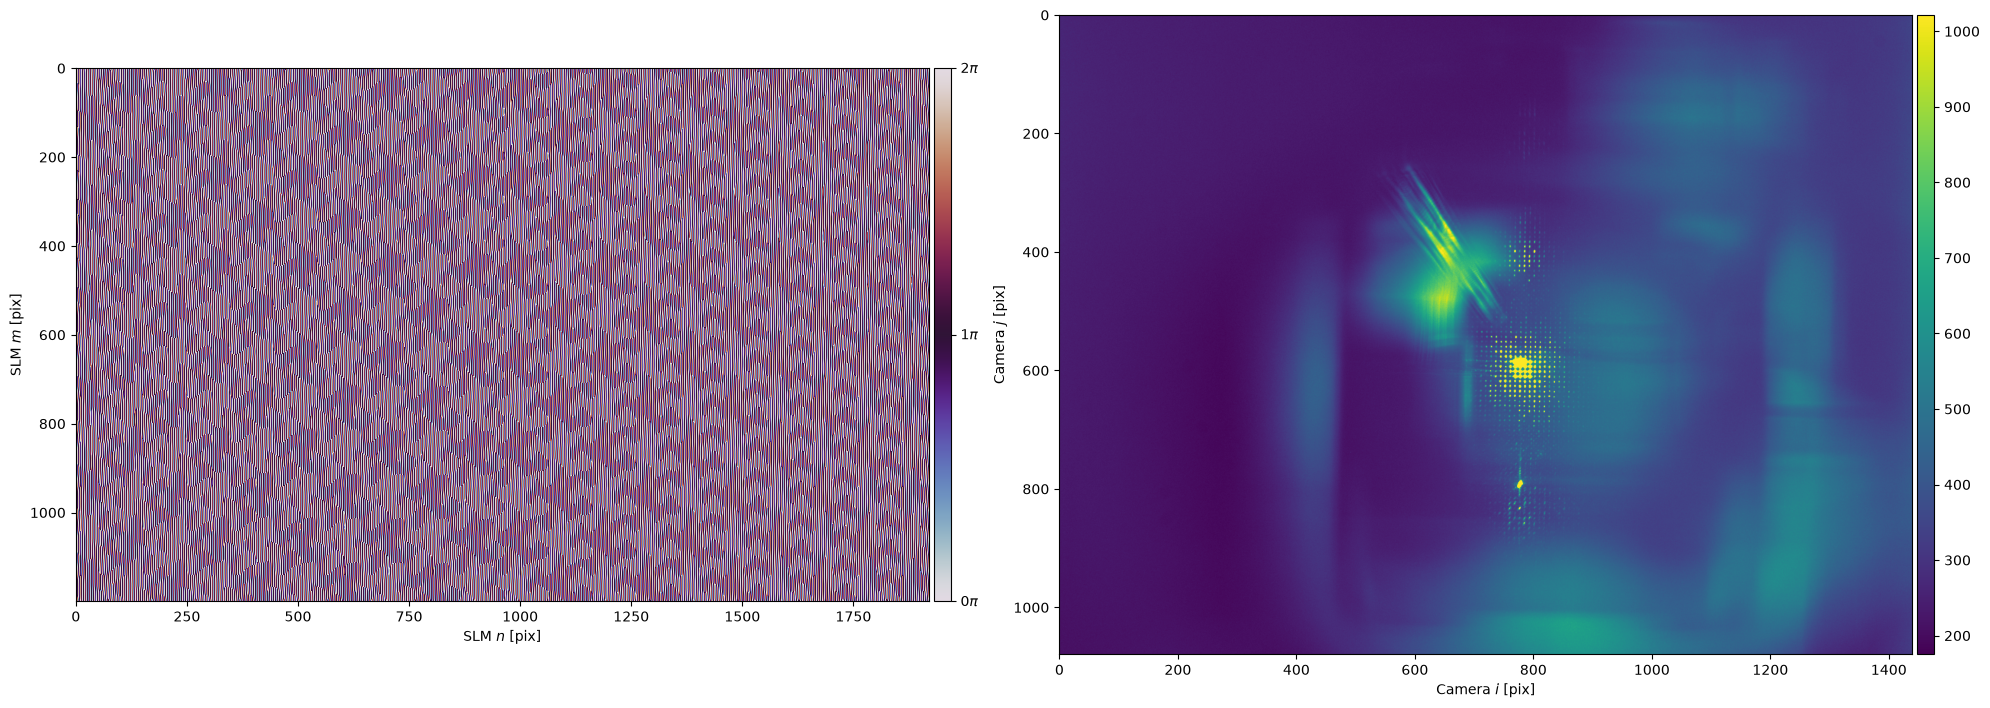

In [15]:
fs.plot(hologram.get_phase())

In [16]:
cam.set_exposure(0.01)

0.009998

In [17]:
fs.cam.set_woi((410, 400, 350, 400))


(410, 400, 350, 400)

(<Axes: xlabel='SLM $n$ [pix]', ylabel='SLM $m$ [pix]'>, <Axes: >)

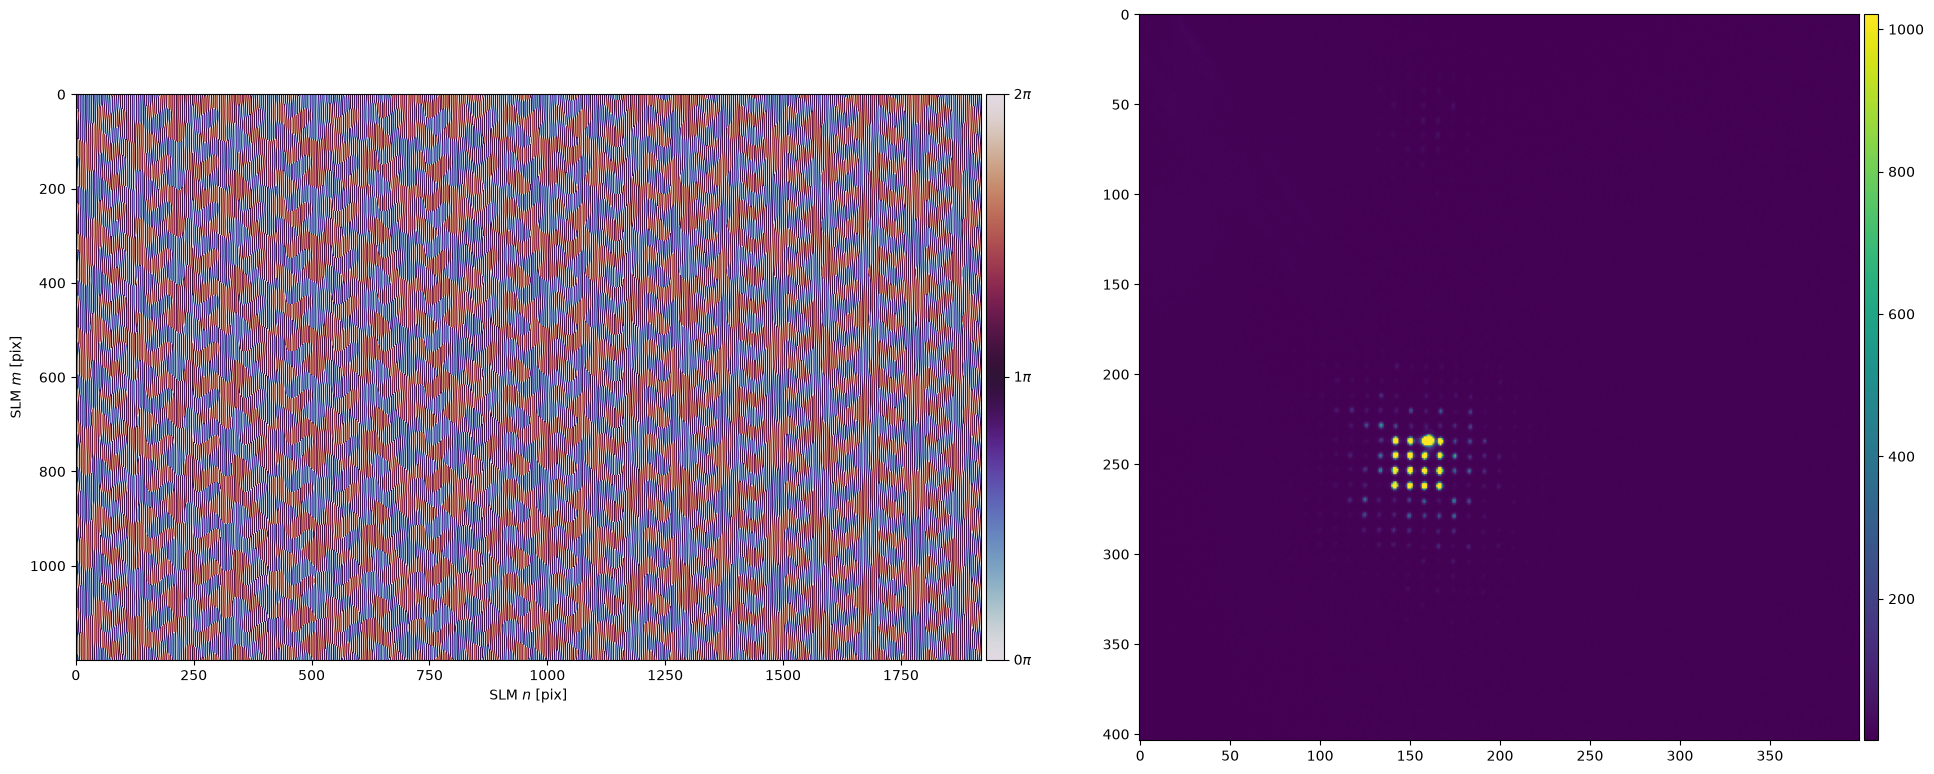

In [18]:
fs.plot(hologram.get_phase())

In [19]:
phase_array = hologram.get_phase()

# save phase_array to a pickle file

with open("4x4_spot_array_phase.pkl", "wb") as f:
    import pickle
    pickle.dump(phase_array, f)

In [20]:
slm.close()

In [21]:
cam.close()